In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import torch.optim as optim
import os
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
from scipy.integrate import trapezoid
from scipy.stats import multivariate_normal
from sklearn.neighbors import KernelDensity
from mpl_toolkits.mplot3d import Axes3D

In [4]:
np.random.seed(42)

dim = 2       

mean1 = np.array([-4,-4])
std1 = 1.0
n_samples1 = 100000

mean2 = np.array([4, 4])
std2 = 2.0
n_samples2 = 10000

data1 = np.random.normal(0, std1, (n_samples1, dim)) + mean1
data2 = np.random.normal(0, std2, (n_samples2, dim)) + mean2
data = np.vstack([data1, data2])

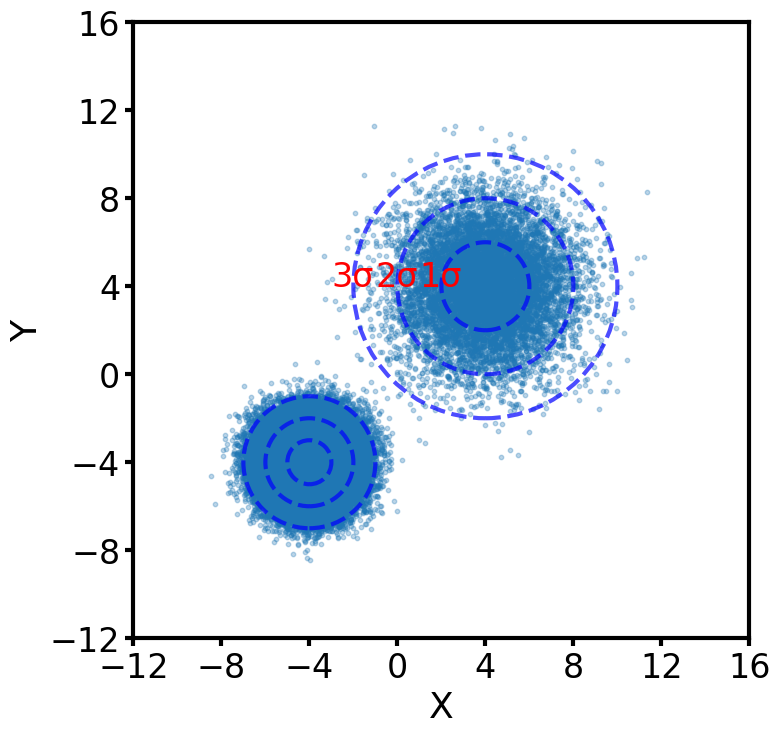

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, s=10)
plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)

for i in range(1, 4):
    circle1 = plt.Circle(mean1, i*std1, fill=False, color='blue', linestyle='--', alpha=0.7, linewidth=3)
    plt.gca().add_patch(circle1)
    circle2 = plt.Circle(mean2, i*std2, fill=False, color='blue', linestyle='--', alpha=0.7, linewidth=3)
    plt.gca().add_patch(circle2)

plt.text(mean2[0]-3, mean2[1], '1σ', fontsize=24, color='red')
plt.text(mean2[0]-5, mean2[1], '2σ', fontsize=24, color='red')
plt.text(mean2[0]-7, mean2[1], '3σ', fontsize=24, color='red')

plt.xlabel('X', fontsize=26)
plt.ylabel('Y', fontsize=26)
plt.xlim(-12, 16)
plt.ylim(-12, 16)
plt.xticks(np.arange(-12, 17, 4))
plt.yticks(np.arange(-12, 17, 4))
plt.tick_params(axis='x', which='major', length=6, labelsize=24, width=3)
plt.tick_params(axis='y', which='major', length=6, labelsize=24, width=3)
plt.setp(plt.gca().spines.values(), linewidth=3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device}")

cuda


In [7]:
class GaussianDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

dataset = GaussianDataset(data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

class ScoreNetwork(nn.Module):
    def __init__(self, dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),  # +1 是时间编码
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )
        
    def forward(self, x, t):
        t = t.reshape(-1, 1)
        x_t = torch.cat([x, t], dim=1)
        return self.net(x_t)

score_model = ScoreNetwork(dim=dim).to(device)
optimizer = optim.Adam(score_model.parameters(), lr=1e-3)

def marginal_prob_std(t, sigma=10.0):
    return torch.sqrt((sigma**(2*t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma=10.0):
    return sigma**t

def loss_fn(model, x, marginal_prob_std, eps=1e-5):
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps  
    z = torch.randn_like(x)
    std = marginal_prob_std(random_t)
    perturbed_x = x + z * std[:, None]
    score = model(perturbed_x, random_t)
    loss = torch.mean(torch.sum((score * std[:, None] + z)**2, dim=1))
    return loss

In [8]:

def visualize_score_potential(model, epoch, device="cuda", resolution=100, range_limit=16, t=0):
    model.eval()
    
    x = np.linspace(-range_limit, range_limit, resolution)
    y = np.linspace(-range_limit, range_limit, resolution)
    X, Y = np.meshgrid(x, y)
    
    grid_points = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), 
                              dtype=torch.float32).to(device)
    
    batch_t = torch.full((grid_points.shape[0],), t, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.suptitle(f'Score Potential Field - Epoch {epoch}, t={t}', fontsize=16)
    
    with torch.no_grad():
        scores = model(grid_points, batch_t).cpu().numpy()
        
        score_x = scores[:, 0].reshape(resolution, resolution)
        score_y = scores[:, 1].reshape(resolution, resolution)
        
        from scipy.interpolate import RegularGridInterpolator
        
        interp_score_x = RegularGridInterpolator((y, x), score_x, method='linear', bounds_error=False, fill_value=0)
        interp_score_y = RegularGridInterpolator((y, x), score_y, method='linear', bounds_error=False, fill_value=0)
        
        potential = np.zeros((resolution, resolution))
        ref_i = np.argmin(np.abs(x - 0)) 
        ref_j = np.argmin(np.abs(y - 0))
        n_steps = 50

        for i in range(resolution):
            for j in range(resolution):
                if i == ref_i and j == ref_j:
                    potential[i, j] = 0
                else:
                    x_start, y_start = x[ref_i], y[ref_j]
                    x_end, y_end = x[i], y[j]
                    
                    t_params = np.linspace(0, 1, n_steps)
                    x_path = x_start + t_params * (x_end - x_start)
                    y_path = y_start + t_params * (y_end - y_start)
                    path_points = np.column_stack([y_path, x_path])
                    
                    scores_x_path = interp_score_x(path_points)
                    scores_y_path = interp_score_y(path_points)
                    
                    dx_step = (x_end - x_start) / (n_steps - 1)
                    dy_step = (y_end - y_start) / (n_steps - 1)
                    
                    integral = np.sum((scores_x_path[:-1] + scores_x_path[1:]) / 2 * dx_step + (scores_y_path[:-1] + scores_y_path[1:]) / 2 * dy_step)
                    potential[i, j] = -integral
        
        im = ax.imshow(potential, extent=[-range_limit, range_limit, -range_limit, range_limit],
                      origin='lower', cmap='viridis', vmin=0, vmax=200)
        plt.colorbar(im, ax=ax, label='Potential Value')
        
        contour = ax.contour(X, Y, potential, 10, colors='white', alpha=0.5)
        ax.clabel(contour, inline=True, fontsize=8)
        
        ax.set_title(f'Potential Field (Optimized Direct Path Integration)')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')
        
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    
    model.train()
    return fig

In [9]:
'''
n_epochs = 50
losses = []
save_interval = 5

score_model.train()

for epoch in range(n_epochs):
    epoch_losses = []
    progress_bar = tqdm(dataloader)
    progress_bar.set_description(f"Epoch {epoch+1}/{n_epochs}")
    
    for x in progress_bar:
        x = x.to(device)
        optimizer.zero_grad()
        loss = loss_fn(score_model, x, marginal_prob_std)
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        progress_bar.set_postfix(loss=loss.item())
        
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_loss:.6f}")

    if (epoch + 1) % save_interval == 0 or epoch == 0:
        print(f"Generating potential field for epoch {epoch+1}")
        visualize_score_potential(score_model, epoch+1, device=device)
    
    if (epoch + 1) % 5 == 0:
        model_path = f"models_plot/score_model_epoch_{epoch+1}.pt"
        torch.save(score_model.state_dict(), model_path)
        print(f"Model saved to {model_path}")

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
'''

model_path = "2D2W_results/diffusion/score_model_epoch_35.pt"
print(f"Loading model: {model_path}")

loaded_score_model = ScoreNetwork(dim=dim).to(device)

loaded_score_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_score_model.eval()
print("Model loaded successfully")

score_model = loaded_score_model

Loading model: 2D2W_results/diffusion/score_model_epoch_35.pt
Model loaded successfully


/tmp/ipykernel_3573308/1963415971.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_score_model.load_state_dict(torch.load(model_path, map_location=device))


In [10]:
def temperature_controlled_sampler_with_two_steps(score_model, marginal_prob_std, diffusion_coeff, 
                                                 batch_size=10, num_steps=1000, clean_steps=1000000,
                                                 device='cuda', eps=1e-3, dim=2, temperature=1.0,
                                                 step_size=0.001, save_trajectory=False, snr=0.16, num_corrector_steps=10):

    score_model.eval()
    
    trajectory = [] if save_trajectory else None
    results = []
    
    print(f"Stage 1: Denoising sampling (T={temperature:.2f})")
    
    t_init = torch.ones(batch_size, device=device)
    x = torch.randn(batch_size, dim, device=device) * marginal_prob_std(t_init)[:, None]
    
    if save_trajectory:
        trajectory.append(x.cpu().numpy().copy())
    
    time_steps = torch.linspace(1.0, eps, num_steps, device=device)
    step_size_time = time_steps[0] - time_steps[1]

    with torch.no_grad():
        for i in tqdm(range(num_steps), desc=f"PC(T={temperature:.2f})"):
            current_t = time_steps[i]
            batch_time_step = torch.ones(batch_size, device=device) * current_t
            
            # ============ Corrector Step (Langevin MCMC) ============
            for _ in range(num_corrector_steps):
                grad = score_model(x, batch_time_step)
                
                grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
                noise_norm = np.sqrt(np.prod(x.shape[1:]))
                langevin_step_size = 2 * (snr * noise_norm / grad_norm) ** 2
                
                x = x + langevin_step_size * grad + torch.sqrt(2 * langevin_step_size * temperature) * torch.randn_like(x)
            
            # ============ Predictor Step (Euler-Maruyama) ============
            score = score_model(x, batch_time_step)
            g_t = diffusion_coeff(batch_time_step)
            
            x_mean = x + (g_t[:, None] ** 2) * score * step_size_time
            x = x_mean + torch.sqrt(g_t[:, None] ** 2 * step_size_time * temperature) * torch.randn_like(x)
            
            if save_trajectory and i % 100 == 0:
                trajectory.append(x.cpu().numpy().copy())
    
    x = x_mean
    
    print(f"Stage 2: Cleaning sampling (T={temperature:.2f})")
    
    clean_time = torch.ones(batch_size, device=device) * (1e-8)
    
    temperature_tensor = torch.tensor(temperature, device=device)
    
    with torch.no_grad():
        
        step_size_tensor = torch.tensor(step_size, device=device)
        
        for i in tqdm(range(clean_steps), desc=f"Clean(T={temperature:.2f})"):
            clean_score = score_model(x, clean_time)
            diffusion_coeff_clean = torch.sqrt(2 * step_size_tensor * temperature_tensor)
            
            drift = clean_score * step_size_tensor
            noise = torch.randn_like(x)
            
            x = x + drift + diffusion_coeff_clean * noise
            
            if i >= (clean_steps - 500000) and i % 1000 == 0:
                results.append(x.cpu().numpy().copy())
            
            if save_trajectory and i % 100 == 0:
                trajectory.append(x.cpu().numpy().copy())
    
    score_model.train()
    
    final_samples = np.vstack(results)
    
    save_dir = "sampling_result"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"samples_T{temperature:.2f}.npy"
    full_save_path = os.path.join(save_dir, filename)
    
    np.save(full_save_path, final_samples)
    print(f"Final samples saved to: {full_save_path}")
    print(f"Sample shape: {final_samples.shape}")

    trajectory_samples = np.vstack(trajectory) 
        
    trajectory_filename = f"trajectory_T{temperature:.2f}.npy"
    trajectory_save_path = os.path.join(save_dir, trajectory_filename)
        
    np.save(trajectory_save_path, trajectory_samples)
    print(f"Trajectory data saved to: {trajectory_save_path}")
    print(f"Trajectory shape: {trajectory_samples.shape}")

    if save_trajectory:
        return torch.tensor(final_samples, device=device), trajectory
    else:
        return torch.tensor(final_samples, device=device)

def sample_at_multiple_temperatures_with_clean(score_model, marginal_prob_std, diffusion_coeff,
                                             temperatures=[0.5, 1.0, 2.0, 4.0], 
                                             batch_size=10, num_steps=1000, clean_steps=1000000,
                                             device='cuda', dim=2, step_size=0.01,
                                             save_trajectory=False, snr=0.16, num_corrector_steps=10):

    results = {}
    trajectories = {} if save_trajectory else None
    
    for temp in temperatures:
        if save_trajectory:
            samples, trajectory = temperature_controlled_sampler_with_two_steps(
                score_model, marginal_prob_std, diffusion_coeff,
                batch_size=batch_size, num_steps=num_steps, clean_steps=clean_steps,
                device=device, dim=dim, temperature=temp, step_size=step_size,
                save_trajectory=True, snr=0.16, num_corrector_steps=num_corrector_steps
            )
            trajectories[temp] = trajectory
        else:
            samples = temperature_controlled_sampler_with_two_steps(
                score_model, marginal_prob_std, diffusion_coeff,
                batch_size=batch_size, num_steps=num_steps, clean_steps=clean_steps,
                device=device, dim=dim, temperature=temp, step_size=step_size,
                save_trajectory=False, snr=0.16, num_corrector_steps=num_corrector_steps
            )
        
        results[temp] = samples.cpu().numpy()
    
    if save_trajectory:
        return results, trajectories
    else:
        return results

'''
if __name__ == "__main__":
    if isinstance(data, torch.Tensor):
        original_data_numpy = data.cpu().numpy()
    else:
        original_data_numpy = data
    
    temperatures = [0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 4.0]
    results, trajectories = sample_at_multiple_temperatures_with_clean(
        score_model, marginal_prob_std, diffusion_coeff,
        temperatures=temperatures,
        batch_size=10,
        num_steps=1000,
        clean_steps=1100000,
        device=device,
        dim=dim,
        step_size=0.001,
        save_trajectory=True
    )
'''

results = {}

temperatures_best = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0]

print("Loading sampling results:")
for temp in temperatures_best:
    file_path = f"2D2W_results/sampling/samples_T{temp:.2f}.npy"
    samples = np.load(file_path)
    results[temp] = samples
    print(f"  Temperature {temp}: Sample shape {samples.shape}")

print(f"\nSuccessfully loaded sampling results for {len(results)} temperatures")

Loading sampling results:
  Temperature 0.2: Sample shape (50000, 2)
  Temperature 0.4: Sample shape (50000, 2)
  Temperature 0.6: Sample shape (50000, 2)
  Temperature 0.8: Sample shape (50000, 2)
  Temperature 1.0: Sample shape (50000, 2)
  Temperature 1.2: Sample shape (50000, 2)
  Temperature 1.4: Sample shape (50000, 2)
  Temperature 1.6: Sample shape (50000, 2)
  Temperature 1.8: Sample shape (50000, 2)
  Temperature 2.0: Sample shape (50000, 2)
  Temperature 2.2: Sample shape (50000, 2)
  Temperature 2.4: Sample shape (50000, 2)
  Temperature 2.6: Sample shape (50000, 2)
  Temperature 2.8: Sample shape (50000, 2)
  Temperature 3.0: Sample shape (50000, 2)
  Temperature 3.2: Sample shape (50000, 2)
  Temperature 3.4: Sample shape (50000, 2)
  Temperature 3.6: Sample shape (50000, 2)
  Temperature 3.8: Sample shape (50000, 2)
  Temperature 4.0: Sample shape (50000, 2)
  Temperature 4.2: Sample shape (50000, 2)
  Temperature 4.4: Sample shape (50000, 2)
  Temperature 4.6: Sample sh


Comparing theoretical and sampled values:
T	Theory<U>	Sampling<U>	Theory<U^2>	Sampling<U^2>	Theory C_v	Sampling C_v
--------------------------------------------------
0.20	0.1860	0.2454	0.0745	0.1117	0.9976	1.2878
0.40	0.3856	0.4533	0.3092	0.3960	1.0030	1.1902
0.60	0.5944	0.6639	0.7563	0.8941	1.1194	1.2592
0.80	0.8492	0.9189	1.6559	1.8403	1.4606	1.5560
1.00	1.1847	1.3152	3.2948	3.9070	1.8913	2.1772
1.20	1.5984	1.8099	5.7496	7.0196	2.2185	2.5998
1.40	2.0599	2.2707	8.8823	10.3413	2.3668	2.6456
1.60	2.5350	2.7210	12.4772	13.7829	2.3636	2.4918
1.80	2.9993	3.1591	16.3459	17.7019	2.2686	2.3832
2.00	3.4397	3.6055	20.3613	21.8643	2.1324	2.2161
2.20	3.8516	4.0163	24.4497	26.1659	1.9865	2.0733
2.40	4.2348	4.3784	28.5735	30.1873	1.8472	1.9127
2.60	4.5914	4.7175	32.7157	34.2619	1.7211	1.7762
2.80	4.9242	5.0274	36.8696	38.4096	1.6099	1.6753
3.00	5.2363	5.3639	41.0334	43.2222	1.5127	1.6057
3.20	5.5302	5.6579	45.2068	47.4142	1.4281	1.5042
3.40	5.8082	5.9249	49.3900	51.6971	1.3542	1.4354
3.60	6.0724	

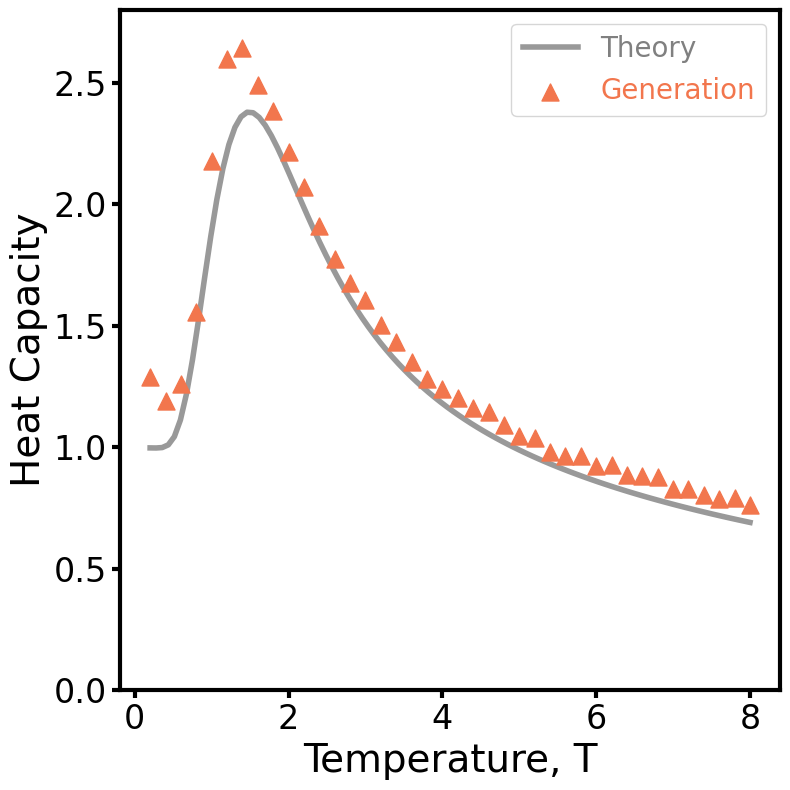


Possible phase transitions found:
Temperature: 1.400, Heat Capacity: 2.646


In [11]:
class ThermalAnalysisWithSampling:
    def __init__(self, score_model, sampling_results, device='cuda', range_limit=16, resolution=100):
        self.score_model = score_model
        self.sampling_results = sampling_results
        self.device = device
        self.range_limit = range_limit
        self.resolution = resolution
        self.dx = 2 * range_limit / resolution
        self.dy = 2 * range_limit / resolution
        
        self.x_grid, self.y_grid, self.potential_field = self._compute_potential_field()
        
        self.temperatures = sorted(sampling_results.keys())
        self._analyze_sampling_thermodynamics()
        
    def _compute_potential_field(self):
        from scipy.interpolate import RegularGridInterpolator

        x = np.linspace(-self.range_limit, self.range_limit, self.resolution)
        y = np.linspace(-self.range_limit, self.range_limit, self.resolution)
        X, Y = np.meshgrid(x, y)
        
        grid_points = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), 
                                  dtype=torch.float32).to(self.device)
        batch_t = torch.zeros(grid_points.shape[0], device=self.device)
        
        self.score_model.eval()
        with torch.no_grad():
            scores = self.score_model(grid_points, batch_t).cpu().numpy()
        
        score_x = scores[:, 0].reshape(self.resolution, self.resolution)
        score_y = scores[:, 1].reshape(self.resolution, self.resolution)
        
        interp_score_x = RegularGridInterpolator((y, x), score_x, method='linear', 
                                                bounds_error=False, fill_value=0)
        interp_score_y = RegularGridInterpolator((y, x), score_y, method='linear', 
                                                bounds_error=False, fill_value=0)

        potential = np.zeros((self.resolution, self.resolution))
        
        ref_i = np.argmin(np.abs(x - 0))
        ref_j = np.argmin(np.abs(y - 0))
        n_steps = 50
    
        dx = x[1] - x[0] if len(x) > 1 else 1.0
        dy = y[1] - y[0] if len(y) > 1 else 1.0

        for i in range(self.resolution):
            for j in range(self.resolution):
                if i == ref_j and j == ref_i: 
                    potential[j, i] = 0
                else:
                    x_start, y_start = x[ref_i], y[ref_j]
                    x_end, y_end = x[i], y[j]

                    t_params = np.linspace(0, 1, n_steps)
                    x_path = x_start + t_params * (x_end - x_start)
                    y_path = y_start + t_params * (y_end - y_start)
                    path_points = np.column_stack([y_path, x_path])
                
                    scores_x_path = interp_score_x(path_points)
                    scores_y_path = interp_score_y(path_points)
                
                    dx_step = (x_end - x_start) / (n_steps - 1)
                    dy_step = (y_end - y_start) / (n_steps - 1)
                
                    integral = np.sum((scores_x_path[:-1] + scores_x_path[1:]) / 2 * dx_step + 
                                    (scores_y_path[:-1] + scores_y_path[1:]) / 2 * dy_step)
                    potential[j, i] = -integral
        potential = potential - np.min(potential)
        return X, Y, potential
    
    def _get_potential_at_points(self, points):
        from scipy.interpolate import RegularGridInterpolator
        
        x_coords = np.linspace(-self.range_limit, self.range_limit, self.resolution)
        y_coords = np.linspace(-self.range_limit, self.range_limit, self.resolution)
        
        interpolator = RegularGridInterpolator(
            (y_coords, x_coords), self.potential_field, 
            bounds_error=False, fill_value=np.inf
        )
        
        potential_values = interpolator(np.column_stack([points[:, 1], points[:, 0]]))
        
        return potential_values
    
    def _analyze_sampling_thermodynamics(self):
        self.sampling_internal_energies = []
        self.sampling_internal_energies_squared = []
        self.sampling_heat_capacities = []
        self.sampling_energy_variances = []
        
        for temp in self.temperatures:
            samples = self.sampling_results[temp]
            
            potential_values = self._get_potential_at_points(samples)
            
            valid_mask = np.isfinite(potential_values)
            valid_potentials = potential_values[valid_mask]
            
            if len(valid_potentials) == 0:
                print(f"Warning: no valid sample points at temperature {temp}")
                continue
            
            mean_energy = np.mean(valid_potentials)
            mean_energy_squared = np.mean(valid_potentials**2)
            energy_variance = mean_energy_squared - mean_energy**2
            
            heat_capacity = energy_variance / (temp**2)
            
            self.sampling_internal_energies.append(mean_energy)
            self.sampling_internal_energies_squared.append(mean_energy_squared)
            self.sampling_heat_capacities.append(heat_capacity)
            self.sampling_energy_variances.append(energy_variance)
    
    def theoretical_boltzmann_distribution(self, temperature):
        if temperature <= 0:
            raise ValueError("Temperature must be positive")
        
        beta = 1.0 / temperature
        boltzmann_factors = np.exp(-beta * self.potential_field)
        
        partition_function = np.sum(boltzmann_factors) * self.dx * self.dy
        probability_density = boltzmann_factors / partition_function
        
        return probability_density, partition_function
    
    def theoretical_internal_energy(self, temperature):
        prob_density, _ = self.theoretical_boltzmann_distribution(temperature)
        internal_energy = np.sum(self.potential_field * prob_density) * self.dx * self.dy
        return internal_energy

    def theoretical_internal_energy_squared(self, temperature):
        prob_density, _ = self.theoretical_boltzmann_distribution(temperature)
        internal_energy_squared = np.sum(self.potential_field**2 * prob_density) * self.dx * self.dy
        return internal_energy_squared
    
    def theoretical_heat_capacity(self, temperature):
        beta = 1.0 / temperature
        prob_density, _ = self.theoretical_boltzmann_distribution(temperature)
        
        mean_energy = np.sum(self.potential_field * prob_density) * self.dx * self.dy
        mean_energy_squared = np.sum(self.potential_field**2 * prob_density) * self.dx * self.dy
        
        energy_variance = mean_energy_squared - mean_energy**2
        heat_capacity = beta**2 * energy_variance
        
        return heat_capacity
    
    def compare_theory_and_sampling(self):
        theoretical_energies = []
        theoretical_energies_squared = []
        theoretical_heat_capacities = []
        
        print("\nComparing theoretical and sampled values:")
        print("T\tTheory<U>\tSampling<U>\tTheory<U^2>\tSampling<U^2>\tTheory C_v\tSampling C_v")
        print("-" * 50)
        
        for i, temp in enumerate(self.temperatures):
            theo_U = self.theoretical_internal_energy(temp)
            theo_U2 = self.theoretical_internal_energy_squared(temp)
            theo_C = self.theoretical_heat_capacity(temp)
            
            theoretical_energies.append(theo_U)
            theoretical_energies_squared.append(theo_U2)
            theoretical_heat_capacities.append(theo_C)
            
            if i < len(self.sampling_internal_energies):
                samp_U = self.sampling_internal_energies[i]
                samp_U2 = self.sampling_internal_energies_squared[i]
                samp_C = self.sampling_heat_capacities[i]
                print(f"{temp:.2f}\t{theo_U:.4f}\t{samp_U:.4f}\t{theo_U2:.4f}\t{samp_U2:.4f}\t{theo_C:.4f}\t{samp_C:.4f}")
        
        return theoretical_energies, theoretical_energies_squared, theoretical_heat_capacities

    def visualize_comprehensive_analysis(self):
        theoretical_energies, theoretical_energies_squared, theoretical_heat_capacities = self.compare_theory_and_sampling()
    
        fig = plt.figure(figsize=(8, 8))
    
        theoretical_energies = np.array(theoretical_energies)
        theoretical_energies_squared = np.array(theoretical_energies_squared)
        theoretical_heat_capacities = np.array(theoretical_heat_capacities)

        sampling_energies = np.array(self.sampling_internal_energies)
        sampling_energies_squared = np.array(self.sampling_internal_energies_squared)
        sampling_heat_capacities = np.array(self.sampling_heat_capacities)
    
        temp_min = min(self.temperatures)
        temp_max = max(self.temperatures)
        temp_dense = np.linspace(temp_min, temp_max, 100)
    
        theoretical_heat_capacities_dense = []
        for temp in temp_dense:
            theo_C = self.theoretical_heat_capacity(temp)
            theoretical_heat_capacities_dense.append(theo_C)
    
        theoretical_heat_capacities_dense = np.array(theoretical_heat_capacities_dense)
    
        color_theoretical = 'gray'
        color_sampling = '#F2764D'

        plt.plot(temp_dense, theoretical_heat_capacities_dense, '-', 
                linewidth=4, color=color_theoretical, alpha=0.8, label='Theory')
        plt.scatter(self.temperatures, self.sampling_heat_capacities, color=color_sampling, s=150, marker='^', 
                    label='Generation', zorder=5)

        plt.xlabel('Temperature, T', fontsize=28)
        plt.ylabel('Heat Capacity', fontsize=28)
        ax = plt.gca()
        ax.spines['top'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['right'].set_color('black')
        plt.setp(ax.spines.values(), linewidth=3)
        ax.grid(False)
        plt.ylim(0, 2.8)
        ax.tick_params(axis='both', which='major', labelsize=24, width=3, length=6)
        plt.setp(plt.gca().spines.values(), linewidth=3)

        legend = plt.legend(fontsize=20)
        legend_colors = [color_theoretical, color_sampling]
        for text, color in zip(legend.get_texts(), legend_colors):
            text.set_color(color)
    
        plt.tight_layout()
        plt.show()


    def find_phase_transitions(self):
        sampling_peaks = []
        if len(self.sampling_heat_capacities) > 2:
            for i in range(1, len(self.sampling_heat_capacities)-1):
                if (self.sampling_heat_capacities[i] > self.sampling_heat_capacities[i-1] and 
                    self.sampling_heat_capacities[i] > self.sampling_heat_capacities[i+1] and
                    self.sampling_heat_capacities[i] > np.mean(self.sampling_heat_capacities) + 
                    0.5 * np.std(self.sampling_heat_capacities)):
                    sampling_peaks.append((self.temperatures[i], self.sampling_heat_capacities[i]))
        
        return sampling_peaks

def run_comprehensive_thermal_analysis(score_model, sampling_results, device='cuda'):
    analyzer = ThermalAnalysisWithSampling(
        score_model, sampling_results, device=device, 
        range_limit=16, resolution=80
    )
    
    analyzer.visualize_comprehensive_analysis()
    
    phase_transitions = analyzer.find_phase_transitions()
    
    if phase_transitions:
        print("\nPossible phase transitions found:")
        for T, C in phase_transitions:
            print(f"Temperature: {T:.3f}, Heat Capacity: {C:.3f}")
    else:
        print("\nNo clear phase transitions found")
    
    return analyzer

if __name__ == "__main__":
    analyzer = run_comprehensive_thermal_analysis(score_model, results, device='cuda')
    pass


Data loading completed, total 40 temperature data points


Grid rows:   0%|          | 0/80 [00:00<?, ?it/s]

Grid rows: 100%|██████████| 80/80 [04:10<00:00,  3.13s/it]


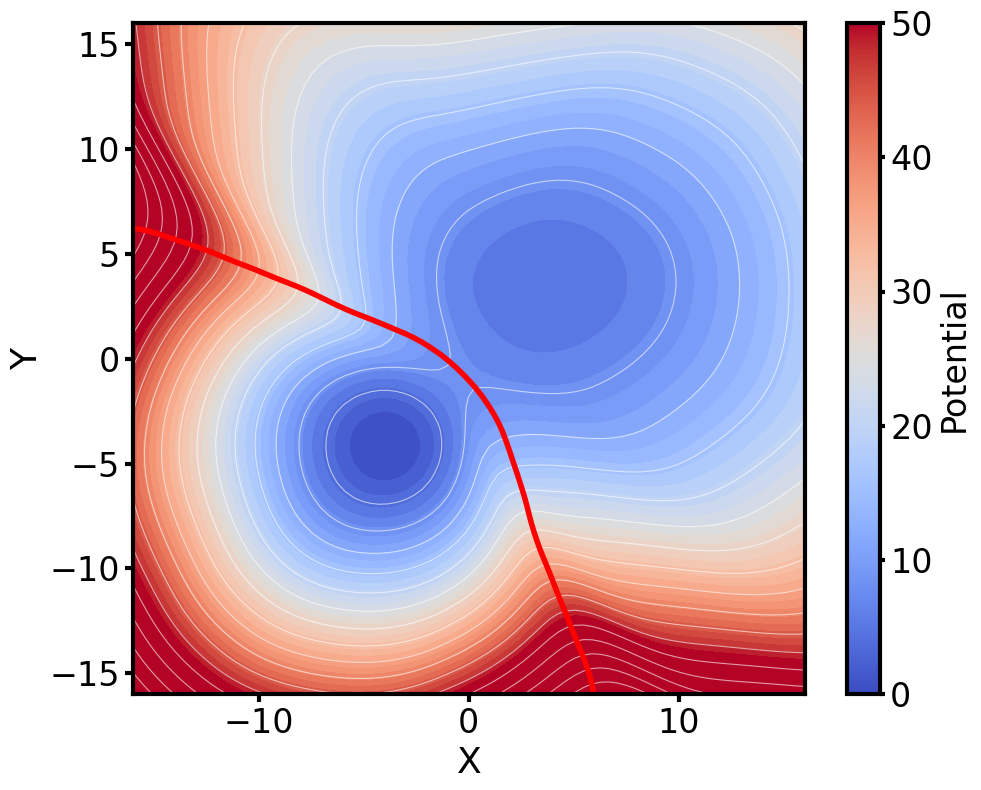

Processing temperatures: 100%|██████████| 40/40 [00:00<00:00, 1866.21it/s]


Temperature 0.2: Region 1 = 100.0%, Region 2 = 0.0%
Temperature 0.4: Region 1 = 100.0%, Region 2 = 0.0%
Temperature 0.6: Region 1 = 99.8%, Region 2 = 0.2%
Temperature 0.8: Region 1 = 98.8%, Region 2 = 1.2%
Temperature 1.0: Region 1 = 95.1%, Region 2 = 4.9%
Temperature 1.2: Region 1 = 89.2%, Region 2 = 10.8%
Temperature 1.4: Region 1 = 83.9%, Region 2 = 16.1%
Temperature 1.6: Region 1 = 78.6%, Region 2 = 21.4%
Temperature 1.8: Region 1 = 73.9%, Region 2 = 26.1%
Temperature 2.0: Region 1 = 68.8%, Region 2 = 31.2%
Temperature 2.2: Region 1 = 64.9%, Region 2 = 35.1%
Temperature 2.4: Region 1 = 61.5%, Region 2 = 38.5%
Temperature 2.6: Region 1 = 58.5%, Region 2 = 41.5%
Temperature 2.8: Region 1 = 56.3%, Region 2 = 43.7%
Temperature 3.0: Region 1 = 54.2%, Region 2 = 45.8%
Temperature 3.2: Region 1 = 51.9%, Region 2 = 48.1%
Temperature 3.4: Region 1 = 50.3%, Region 2 = 49.7%
Temperature 3.6: Region 1 = 49.2%, Region 2 = 50.8%
Temperature 3.8: Region 1 = 47.6%, Region 2 = 52.4%
Temperature 4.0

Computing theoretical values: 100%|██████████| 100/100 [00:00<00:00, 10081.98it/s]


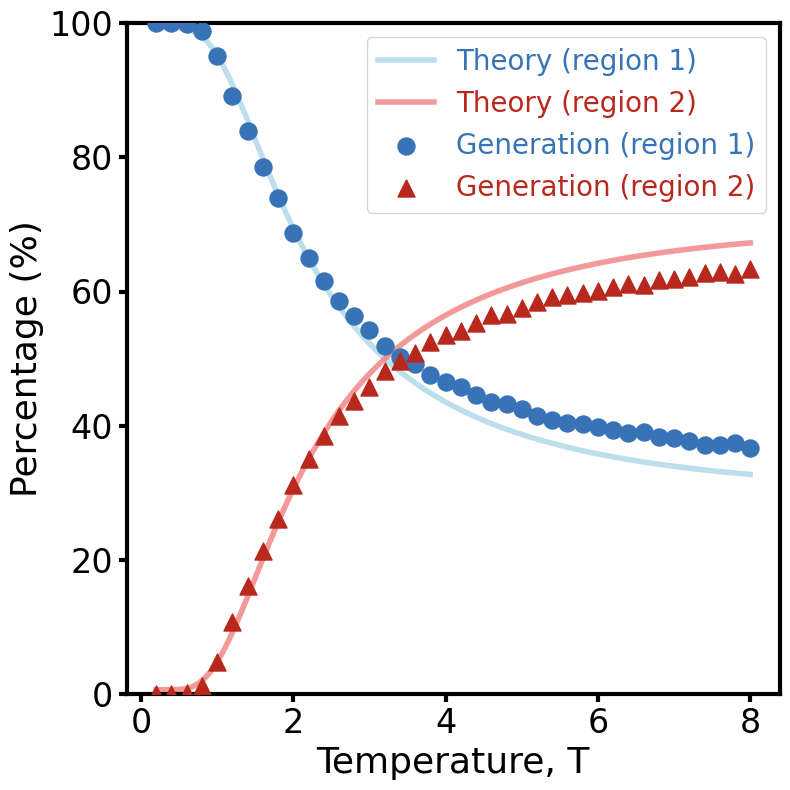

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from sklearn.metrics.pairwise import euclidean_distances
from scipy.ndimage import label, gaussian_filter
from skimage import measure

def compute_basin_map_smooth(X, Y, potential, step_size=0.05, max_steps=1000, smooth_sigma=2.0):
    resolution = X.shape[0]
    basin_map = np.zeros_like(potential, dtype=float)
    
    well_positions = np.array([[-4, -4], [4, 4]])
    
    for i in tqdm(range(resolution), desc="Grid rows"):
        for j in range(resolution):
            current_x = X[i, j]
            current_y = Y[i, j]
            
            for step in range(max_steps):
                grad_x, grad_y = compute_potential_gradient_at_point(
                    current_x, current_y, X, Y, potential
                )
                
                new_x = current_x - step_size * grad_x
                new_y = current_y - step_size * grad_y
                
                displacement = np.sqrt((new_x - current_x)**2 + (new_y - current_y)**2)
                if displacement < 1e-4:
                    break
                
                current_x, current_y = new_x, new_y
            
            final_pos = np.array([current_x, current_y])
            distances = np.linalg.norm(well_positions - final_pos, axis=1)
            closest_well = np.argmin(distances)
            
            basin_map[i, j] = closest_well + 1
    
    basin_map_smooth = gaussian_filter(basin_map.astype(float), sigma=smooth_sigma)
    
    return basin_map_smooth

def compute_potential_gradient_at_point(x, y, X, Y, potential):
    resolution = X.shape[0]
    x_min, x_max = X[0, 0], X[0, -1]
    y_min, y_max = Y[0, 0], Y[-1, 0]
    
    x = np.clip(x, x_min, x_max)
    y = np.clip(y, y_min, y_max)
    
    dx = (x_max - x_min) / (resolution - 1)
    dy = (y_max - y_min) / (resolution - 1)
    
    i_float = (y - y_min) / dy
    j_float = (x - x_min) / dx
    
    i = int(np.floor(i_float))
    j = int(np.floor(j_float))
    
    i = np.clip(i, 0, resolution - 2)
    j = np.clip(j, 0, resolution - 2)
    
    if j > 0 and j < resolution - 1:
        grad_x = (potential[i, j + 1] - potential[i, j - 1]) / (2 * dx)
    elif j == 0:
        grad_x = (potential[i, j + 1] - potential[i, j]) / dx
    else:
        grad_x = (potential[i, j] - potential[i, j - 1]) / dx
    
    if i > 0 and i < resolution - 1:
        grad_y = (potential[i + 1, j] - potential[i - 1, j]) / (2 * dy)
    elif i == 0:
        grad_y = (potential[i + 1, j] - potential[i, j]) / dy
    else:
        grad_y = (potential[i, j] - potential[i - 1, j]) / dy
    
    return grad_x, grad_y

def classify_samples_using_basin_map(samples, X, Y, basin_map):    
    n_samples = len(samples)
    
    x_min, x_max = X[0, 0], X[0, -1]
    y_min, y_max = Y[0, 0], Y[-1, 0]
    resolution = X.shape[0]
    
    x_coords = samples[:, 0]
    y_coords = samples[:, 1]
    
    x_coords = np.clip(x_coords, x_min, x_max)
    y_coords = np.clip(y_coords, y_min, y_max)
    
    i_indices = ((y_coords - y_min) / (y_max - y_min) * (resolution - 1)).astype(int)
    j_indices = ((x_coords - x_min) / (x_max - x_min) * (resolution - 1)).astype(int)
    
    i_indices = np.clip(i_indices, 0, resolution - 1)
    j_indices = np.clip(j_indices, 0, resolution - 1)
    
    basin_values = basin_map[i_indices, j_indices]
    
    region1_mask = basin_values < 1.5
    region2_mask = basin_values >= 1.5
    
    region1_percent = np.sum(region1_mask) / n_samples * 100
    region2_percent = np.sum(region2_mask) / n_samples * 100
    
    return {
        'region1_percent': region1_percent,
        'region2_percent': region2_percent,
        'basin_values': basin_values
    }

def analyze_all_temperatures_with_basin_map(results_dict, X, Y, basin_map):
    percentages = {}
    
    for temp in tqdm(sorted(results_dict.keys()), desc="Processing temperatures"):
        samples = results_dict[temp]
        
        result = classify_samples_using_basin_map(samples, X, Y, basin_map)
        
        percentages[temp] = {
            'region1_percent': result['region1_percent'],
            'region2_percent': result['region2_percent']
        }
        
        print(f"Temperature {temp}: Region 1 = {result['region1_percent']:.1f}%, Region 2 = {result['region2_percent']:.1f}%")
    
    return percentages

def calculate_theoretical_ratios_with_basin_map(X, Y, potential, basin_map, temperatures):
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    
    ratios_data = {}
    
    for temp in tqdm(temperatures, desc="Computing theoretical values"):
        boltzmann_temp = np.exp(-potential / temp)

        weight_region1 = 1 / (1 + np.exp(10 * (basin_map - 1.5)))
        weight_region2 = 1 - weight_region1
        
        region1_mass = np.sum(boltzmann_temp * weight_region1) * dx * dy
        region2_mass = np.sum(boltzmann_temp * weight_region2) * dx * dy
        total_mass = region1_mass + region2_mass
        
        if total_mass > 0:
            region1_percent = region1_mass / total_mass * 100
            region2_percent = region2_mass / total_mass * 100
        else:
            region1_percent = 50.0
            region2_percent = 50.0
        
        ratios_data[temp] = {
            'region1_percent': region1_percent,
            'region2_percent': region2_percent
        }
    
    return ratios_data

def visualize_basin_map_single(X, Y, potential, basin_map, contour_levels=10):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.contourf(X, Y, potential, levels=50, cmap='coolwarm', vmin=0, vmax=50)
    
    contour = ax.contour(X, Y, potential, levels=20, colors='white', alpha=0.6, linewidths=0.8)
    
    main_boundary = ax.contour(X, Y, basin_map, levels=[1.5], 
                               colors=['red'], linewidths=4, alpha=1.0)
    
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_xlabel('X', fontsize=26)
    ax.set_ylabel('Y', fontsize=26)
    ax.set_aspect('equal')
    ax.tick_params(axis='both', which='major', labelsize=24, width=3, length=6)
    plt.setp(ax.spines.values(), linewidth=3)
    
    norm = plt.Normalize(vmin=0, vmax=50)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='coolwarm'), ax=ax, label='Potential')
    cbar.ax.tick_params(labelsize=24)
    cbar.set_label('Potential', fontsize=24)
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(3)
    cbar.ax.tick_params(width=3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_percentage_with_theory(sampling_percentages, theoretical_percentages):
    actual_temps = sorted(sampling_percentages.keys())
    actual_region1_ratios = [sampling_percentages[temp]['region1_percent'] for temp in actual_temps]
    actual_region2_ratios = [sampling_percentages[temp]['region2_percent'] for temp in actual_temps]
    
    theory_temps = sorted(theoretical_percentages.keys())
    theory_region1_ratios = [theoretical_percentages[temp]['region1_percent'] for temp in theory_temps]
    theory_region2_ratios = [theoretical_percentages[temp]['region2_percent'] for temp in theory_temps]
    
    color_theory_r1  = 'lightblue'
    color_theory_r2  = 'lightcoral'
    color_sample_r1  = '#3773B6'
    color_sample_r2  = '#B8281D'

    fig = plt.figure(figsize=(8, 8))
    
    plt.plot(theory_temps, theory_region1_ratios, '-', color=color_theory_r1, linewidth=4, 
             label='Theory (region 1)', alpha=0.8)
    plt.plot(theory_temps, theory_region2_ratios, '-', color=color_theory_r2, linewidth=4, 
             label='Theory (region 2)', alpha=0.8)
    
    plt.scatter(actual_temps, actual_region1_ratios, color=color_sample_r1, s=150, marker='o', 
               label='Generation (region 1)', zorder=5)
    plt.scatter(actual_temps, actual_region2_ratios, color=color_sample_r2, s=150, marker='^', 
               label='Generation (region 2)', zorder=5)
    
    ax = plt.gca()
    ax.spines['top'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    plt.setp(ax.spines.values(), linewidth=3)
    ax.grid(False)
    
    plt.xlabel('Temperature, T', fontsize=26)
    plt.ylabel('Percentage (%)', fontsize=26)
    ax.tick_params(axis='both', which='major', labelsize=24, width=3, length=6)
    plt.ylim(0, 100)

    legend = plt.legend(fontsize=20)
    legend_colors = [color_sample_r1, color_sample_r2, color_sample_r1, color_sample_r2]
    for text, color in zip(legend.get_texts(), legend_colors):
        text.set_color(color)

    plt.tight_layout()
    plt.show()

def complete_analysis_with_precomputed_basin_map(results_dict, X, Y, potential, smooth_sigma=2.0):
    if len(results_dict) == 0:
        print("No data was successfully loaded, please check the file paths")
        return None, None, None
    
    print(f"\nData loading completed, total {len(results_dict)} temperature data points")
    
    basin_map = compute_basin_map_smooth(X, Y, potential, smooth_sigma=smooth_sigma)
    
    visualize_basin_map_single(X, Y, potential, basin_map)
    
    sampling_percentages = analyze_all_temperatures_with_basin_map(results_dict, X, Y, basin_map)
    
    temperatures = sorted(results_dict.keys())
    temp_dense = np.linspace(min(temperatures), max(temperatures), 100)
    theoretical_percentages = calculate_theoretical_ratios_with_basin_map(X, Y, potential, basin_map, temp_dense)
    
    plot_percentage_with_theory(sampling_percentages, theoretical_percentages)
    
    return sampling_percentages, theoretical_percentages, basin_map

X         = analyzer.x_grid
Y         = analyzer.y_grid
potential = analyzer.potential_field

sampling_percentages, theoretical_percentages, basin_map = complete_analysis_with_precomputed_basin_map(
    results, X, Y, potential, smooth_sigma=2.0
)